In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df= pd.read_csv('/content/DailyDelhiClimateTest.csv')
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [34]:
df= df[['date','meantemp']]
df.sample()

,date,meantemp
47,2017-02-17,21.3


using inbuilt function to calculate exponentially weighted movinf average

In [35]:
x1= df['meantemp'].ewm(alpha=0.9).mean()
x1

,meantemp
0,15.913043
1,18.264822
2,17.225443
3,18.552677
4,18.405266
...,...
109,34.403401
110,34.265340
111,33.036534
112,32.891153


In [36]:
df['ewma']=x1
df.head()

,date,meantemp,ewma
0,2017-01-01,15.913043,15.913043
1,2017-01-02,18.500000,18.264822
2,2017-01-03,17.111111,17.225443
3,2017-01-04,18.700000,18.552677
4,2017-01-05,18.388889,18.405266


plotting the graph

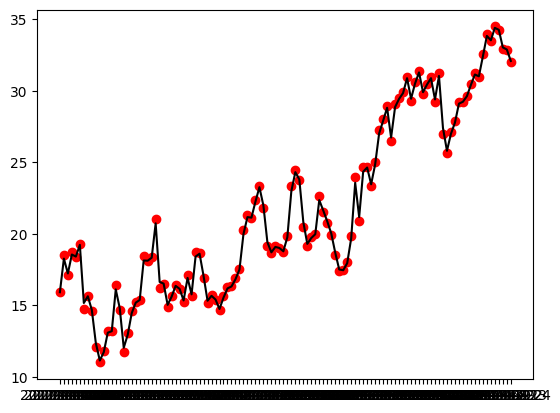

In [37]:
plt.scatter(x=df['date'], y=df['meantemp'], color='red')
plt.plot(df['date'], df['ewma'], color= 'black')
plt.show()

self coding the logic of EWMA

In [38]:
def ewma(alpha, data):
  ewma_data=[]
  ewma_data.append(data[0])
  for i in range(1, len(data)):
    temp= alpha* data[i]+ (1-alpha)* ewma_data[i-1]
    ewma_data.append(temp)

  return ewma_data

In [39]:
df['ewma_self']= ewma(0.9, df['meantemp'])

plotting graph to check our accuracy

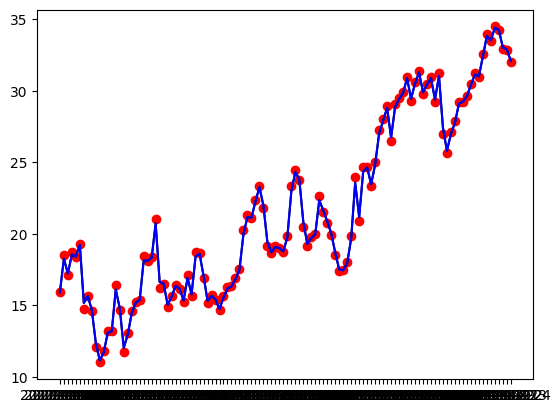

In [40]:
plt.scatter(x=df['date'], y=df['meantemp'], color='red')
plt.plot(df['date'], df['ewma'], color= 'black')
plt.plot(df['date'], df['ewma_self'], color='blue')
plt.show()